<a href="https://colab.research.google.com/github/jumbokh/ml-class2025/blob/main/lab/GPT_program3_seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind

In [2]:
# === 1. 資料載入 ===
data = pd.read_excel("simulated_student_data.xlsx")

In [3]:
# === 2. 特徵欄位與標籤 ===
features = ['参与10%', '平时30%', '期中考20%', '期末考40%', '总成绩']
X = data[features]
y = data['组别']  # 0 = 對照組, 1 = 處理組

In [4]:
# === 3. 資料標準化 ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# === 4. 分層抽樣切分訓練/測試集 ===
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [6]:
# === 5. 模型訓練 ===
log_model = LogisticRegression().fit(X_train, y_train)
mlp_model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
svm_model = SVC(kernel='rbf', probability=True, random_state=42).fit(X_train, y_train)


In [7]:
# === 6. 預測與準確率 ===
log_pred = log_model.predict(X_test)
mlp_pred = mlp_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

print("=== 模型準確率比較 ===")
models = {
    "Logistic Regression": log_pred,
    "MLP Neural Network": mlp_pred,
    "Random Forest": rf_pred,
    "SVM (RBF Kernel)": svm_pred
}

for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    print(f"{name}: Accuracy = {acc:.2%}")

=== 模型準確率比較 ===
Logistic Regression: Accuracy = 83.33%
MLP Neural Network: Accuracy = 83.33%
Random Forest: Accuracy = 77.78%
SVM (RBF Kernel): Accuracy = 77.78%


In [8]:
# === 7. T檢驗分析 ===
print("\n=== T-Test 分析 ===")
control_group = data[data['组别'] == 0][features]
treatment_group = data[data['组别'] == 1][features]

for feature in features:
    t_stat, p_value = ttest_ind(control_group[feature], treatment_group[feature], equal_var=False)
    print(f"{feature}: t = {t_stat:.4f}, p = {p_value:.4f} {'*顯著差異*' if p_value < 0.05 else ''}")



=== T-Test 分析 ===
参与10%: t = 3.3289, p = 0.0016 *顯著差異*
平时30%: t = 3.5197, p = 0.0009 *顯著差異*
期中考20%: t = 2.6702, p = 0.0099 *顯著差異*
期末考40%: t = 2.8668, p = 0.0059 *顯著差異*
总成绩: t = 5.3322, p = 0.0000 *顯著差異*


--2025-06-11 10:48:57--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 173.194.174.139, 173.194.174.113, 173.194.174.102, ...
Connecting to drive.google.com (drive.google.com)|173.194.174.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-06-11 10:48:58--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.203.132, 2404:6800:4008:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.203.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  --.-KB/s    in 0.1s    

2025-06-11 10

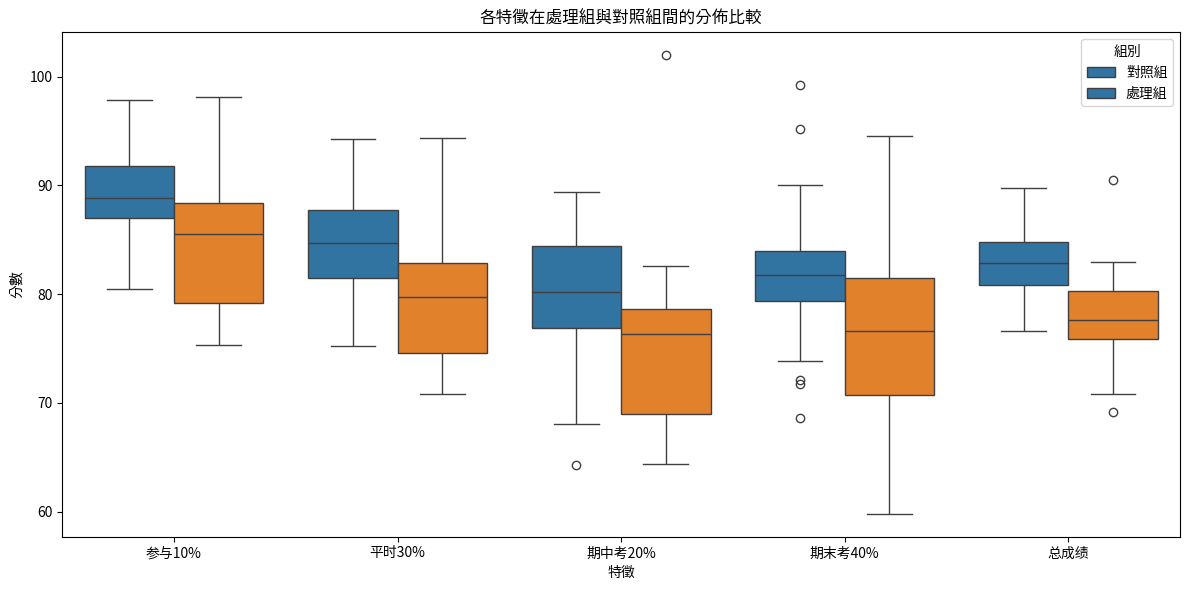

In [13]:
# === 8. 箱型圖視覺化 ===
#plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 修改中文字體
#plt.rcParams['axes.unicode_minus'] = False # 顯示負號
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
# 改style要在改font之前
# plt.style.use('seaborn')
import matplotlib
matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')
plt.figure(figsize=(12, 6))
melted = pd.melt(data, id_vars=['组别'], value_vars=features)
sns.boxplot(data=melted, x='variable', y='value', hue='组别')
plt.title("各特徵在處理組與對照組間的分佈比較")
plt.xlabel("特徵")
plt.ylabel("分數")
plt.legend(title="組別", labels=["對照組", "處理組"])
plt.tight_layout()
plt.show()

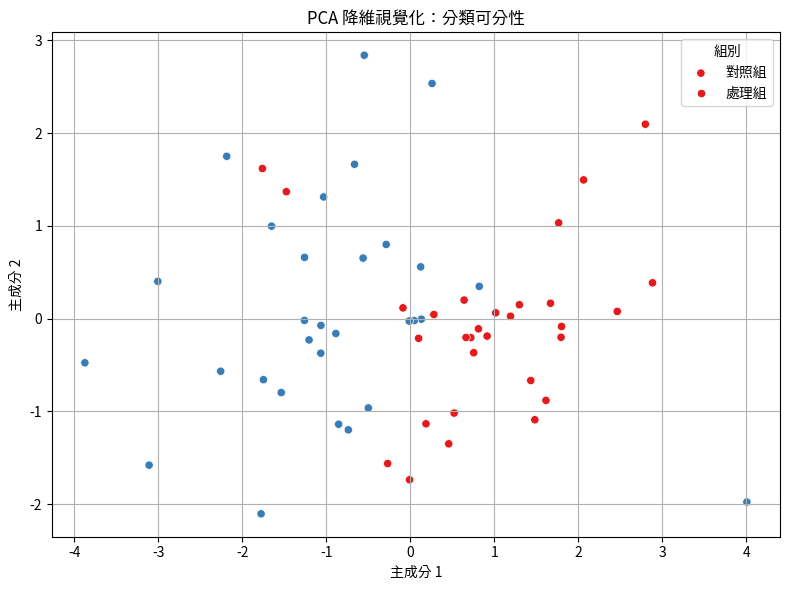

In [14]:
# === 9. PCA 降維視覺化 ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df['组别'] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='组别', palette='Set1')
plt.title("PCA 降維視覺化：分類可分性")
plt.xlabel("主成分 1")
plt.ylabel("主成分 2")
plt.legend(title="組別", labels=["對照組", "處理組"])
plt.grid(True)
plt.tight_layout()
plt.show()